In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
dataset = pd.read_csv(r"D:\data science projecta\iris_rawdata.csv")

In [54]:
dataset.head(3)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2


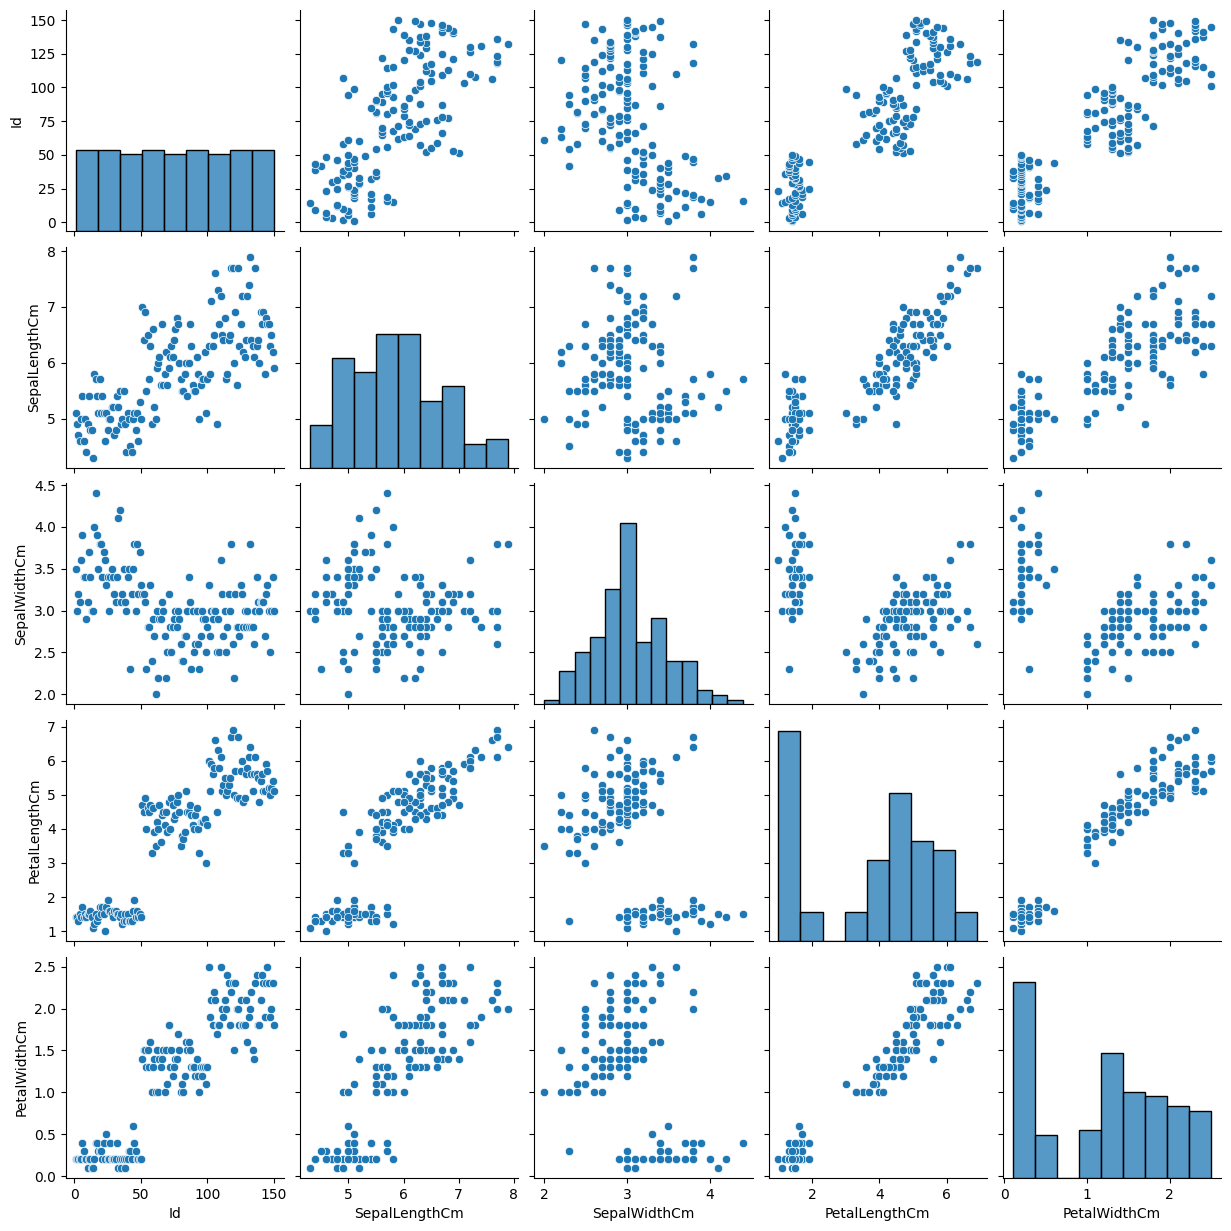

In [55]:
sns.pairplot(data=dataset)
plt.show()

In [8]:
from sklearn.cluster import KMeans

In [9]:
wcss = []
for i in range(2,20):
    km = KMeans( n_clusters=i , init='k-means++')
    km.fit(dataset)
    wcss.append(km.inertia_)

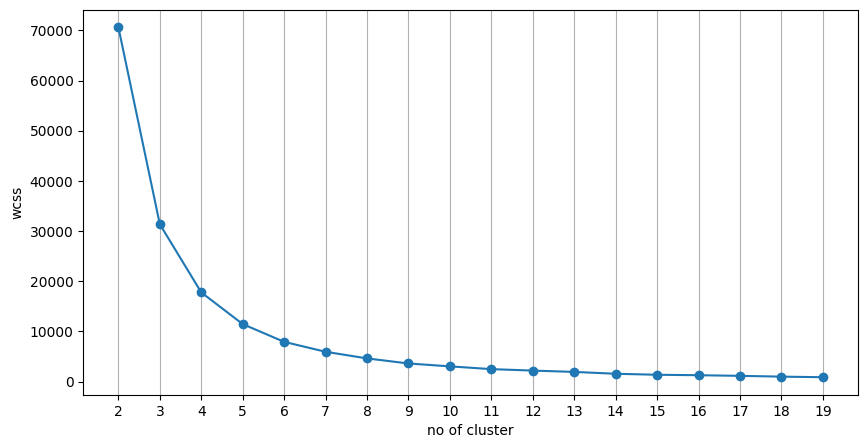

In [14]:
plt.figure(figsize=(10,5))
plt.plot([i for i in range(2,20)],wcss,marker="o")
plt.xlabel("no of cluster")
plt.xticks([i for i in range(2,20)])
plt.ylabel("wcss")
plt.grid(axis="x")
plt.show()

In [56]:
kmn = KMeans(n_clusters=3)
dataset["predict"] = kmn.fit_predict(dataset)

In [31]:
kmn.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [19]:
dataset.head(4)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,predict
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0


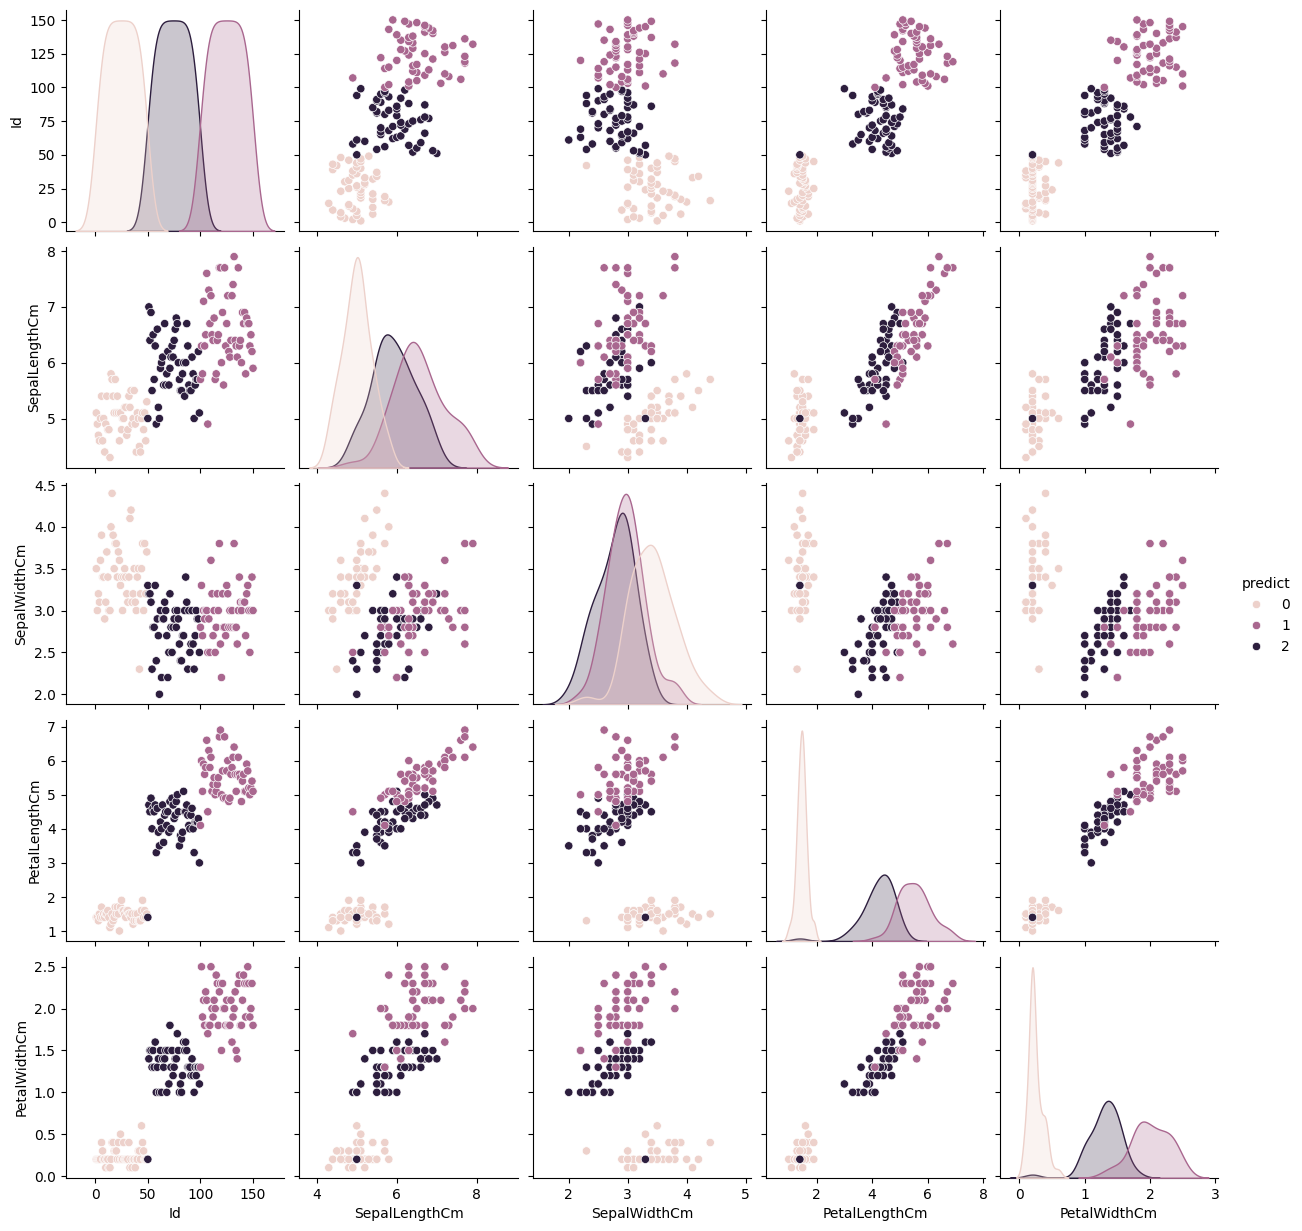

In [20]:
sns.pairplot(data=dataset,hue="predict")
plt.show()

In [27]:
org_dataset = pd.read_csv(r"D:\data science projecta\iris_org.csv")

In [28]:
org_dataset.head(4)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa


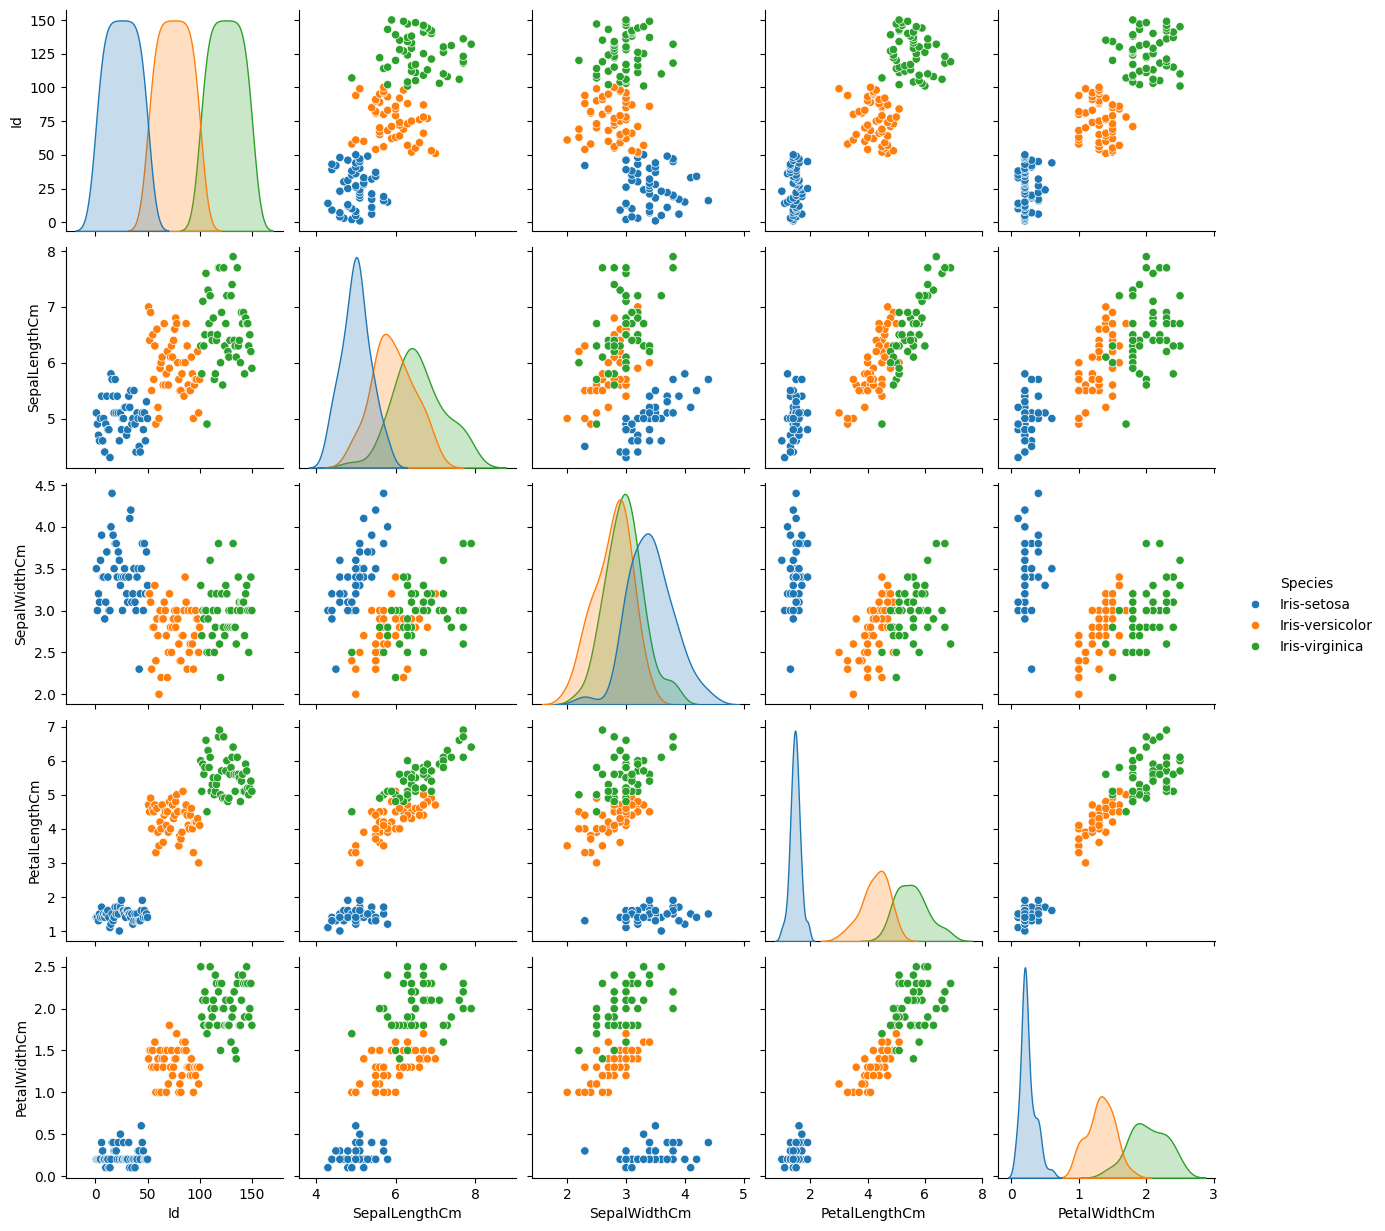

In [30]:
sns.pairplot(data=org_dataset,hue="Species")
plt.show()

# silhouette score

In [46]:
from sklearn.metrics import silhouette_score

In [57]:
ss = silhouette_score(dataset,labels=kmn.labels_)

In [58]:
ss

0.5821251808337136

In [48]:
ss = []
no_c = [j for j in range(2,20)]
for i in range(2,20):
    km1=KMeans( n_clusters=i)
    km1.fit(dataset)
    ss.append(silhouette_score(dataset,km1.labels_))

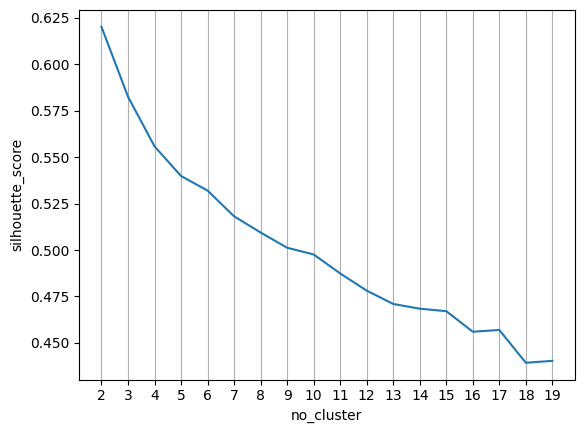

In [49]:
plt.plot(no_c,ss)
plt.xlabel("no_cluster")
plt.ylabel("silhouette_score")
plt.xticks(no_c)
plt.grid(axis="x")
plt.show()